In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
housing= pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


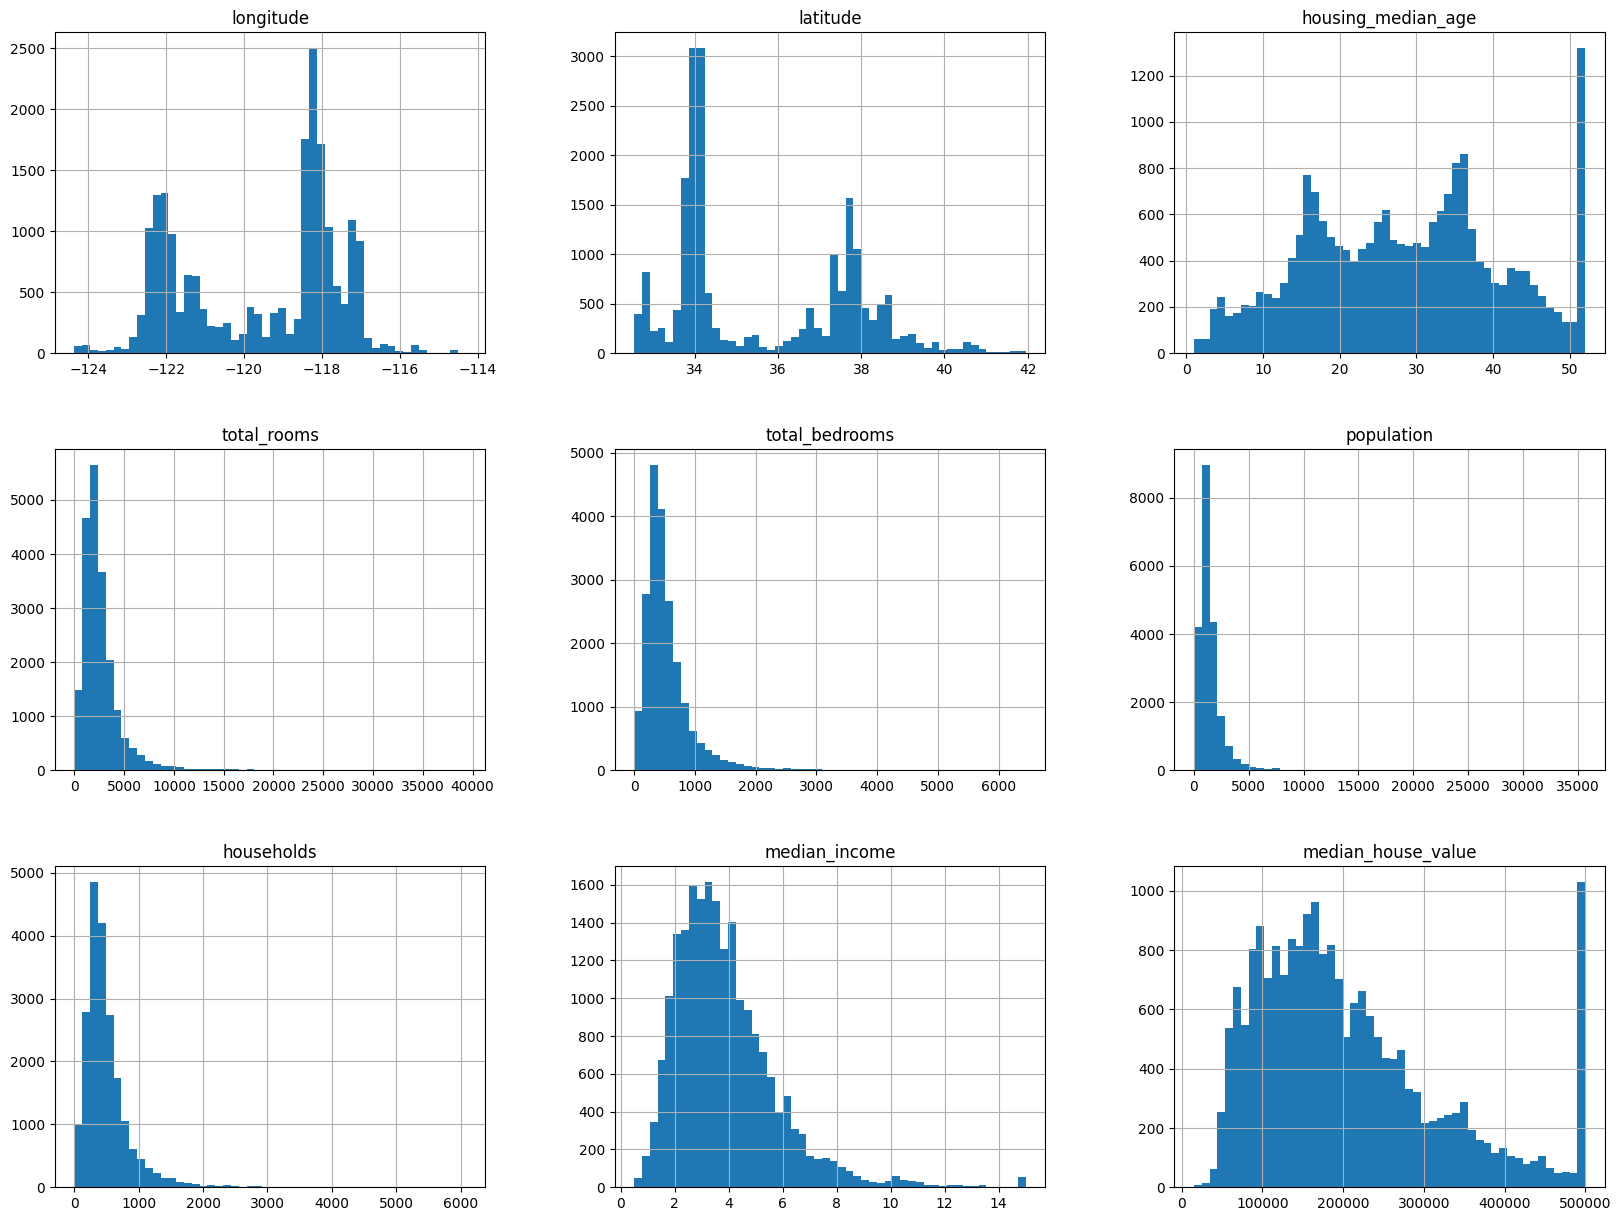

In [9]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

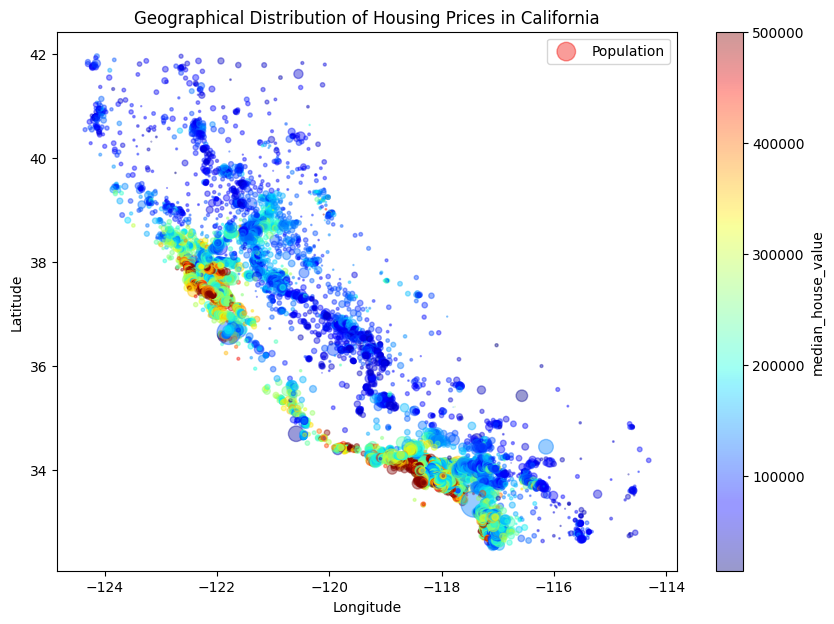

In [11]:
import matplotlib.pyplot as plt

housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"] / 100,
    label="Population",
    figsize=(10,7),
    c="median_house_value",
    cmap="jet",
    colorbar=True
)

plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Housing Prices in California")
plt.show()


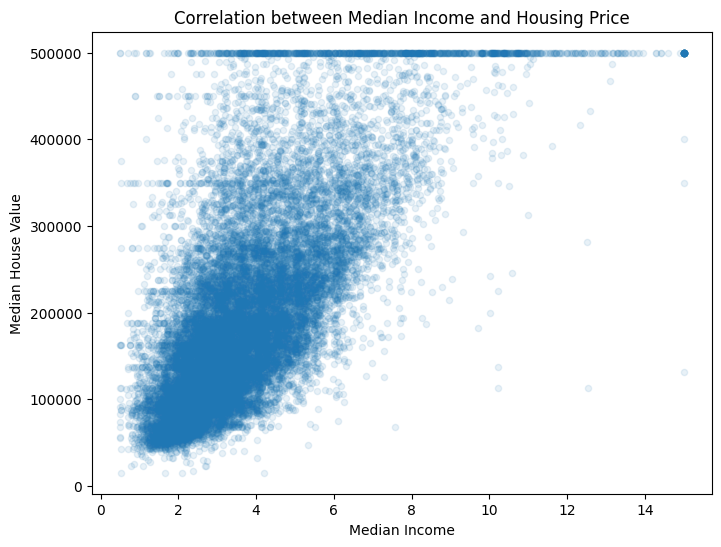

In [12]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1,
    figsize=(8,6)
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Correlation between Median Income and Housing Price")
plt.show()


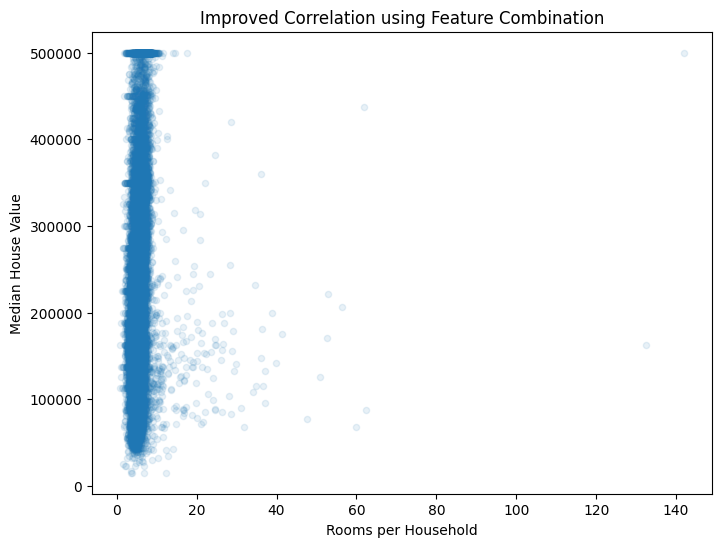

In [13]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]

corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

housing.plot(
    kind="scatter",
    x="rooms_per_household",
    y="median_house_value",
    alpha=0.1,
    figsize=(8,6)
)

plt.xlabel("Rooms per Household")
plt.ylabel("Median House Value")
plt.title("Improved Correlation using Feature Combination")
plt.show()


In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Handle missing values
housing['total_bedrooms'].fillna(housing['total_bedrooms'].median(), inplace=True)

# 2. Encode categorical feature
housing = pd.get_dummies(housing, columns=['ocean_proximity'], drop_first=True)

# 3. Scale numerical features
num_cols = [
    'longitude','latitude','housing_median_age','total_rooms',
    'total_bedrooms','population','households','median_income'
]

scaler = StandardScaler()
housing[num_cols] = scaler.fit_transform(housing[num_cols])


/tmp/ipython-input-3708882107.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['total_bedrooms'].fillna(housing['total_bedrooms'].median(), inplace=True)


In [20]:
# Strip any leading/trailing spaces from column names
housing.columns = housing.columns.str.strip()

# One-Hot Encode the categorical feature
housing_encoded = pd.get_dummies(housing, columns=['ocean_proximity'], drop_first=True)

# Display first 5 rows
print(housing_encoded.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                   False                      True   
1     